<a href="https://colab.research.google.com/github/Sruthireddy2006/Information-retrieval-system/blob/main/Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Generate a simple dataset

In [2]:
np.random.seed(42)

X = np.random.randn(500, 2)

y = ((X[:,0] + X[:,1]) > 0).astype(int)
y = y.reshape(-1,1)

Intialize Parameters

In [3]:
input_size = 2
hidden1 = 8
hidden2 = 6
output_size = 1

W1 = np.random.randn(input_size, hidden1) * 0.1
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.1
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * 0.1
b3 = np.zeros((1, output_size))

Activation function

In [4]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

Training

In [5]:
learning_rate = 0.01
epochs = 1000

losses = []

for epoch in range(epochs):

    # Forward Pass
    z1 = np.dot(X,W1)+b1
    a1 = relu(z1)

    z2 = np.dot(a1,W2)+b2
    a2 = relu(z2)

    z3 = np.dot(a2,W3)+b3
    output = sigmoid(z3)

    # Loss
    loss = np.mean((output-y)**2)
    losses.append(loss)

    # Backpropagation
    d_output = (output-y)*(output*(1-output))

    dW3 = np.dot(a2.T,d_output)
    db3 = np.sum(d_output,axis=0,keepdims=True)

    d_hidden2 = np.dot(d_output,W3.T)*relu_derivative(z2)
    dW2 = np.dot(a1.T,d_hidden2)
    db2 = np.sum(d_hidden2,axis=0,keepdims=True)

    d_hidden1 = np.dot(d_hidden2,W2.T)*relu_derivative(z1)
    dW1 = np.dot(X.T,d_hidden1)
    db1 = np.sum(d_hidden1,axis=0,keepdims=True)

    # Update
    W3 -= learning_rate*dW3
    b3 -= learning_rate*db3

    W2 -= learning_rate*dW2
    b2 -= learning_rate*db2

    W1 -= learning_rate*dW1
    b1 -= learning_rate*db1

    if epoch%100==0:
        print(f"Epoch {epoch} Loss {loss:.4f}")

Epoch 0 Loss 0.2503
Epoch 100 Loss 0.0073
Epoch 200 Loss 0.0044
Epoch 300 Loss 0.0047
Epoch 400 Loss 0.0041
Epoch 500 Loss 0.0038
Epoch 600 Loss 0.0036
Epoch 700 Loss 0.0034
Epoch 800 Loss 0.0033
Epoch 900 Loss 0.0032


In [ ]:
Plot loss

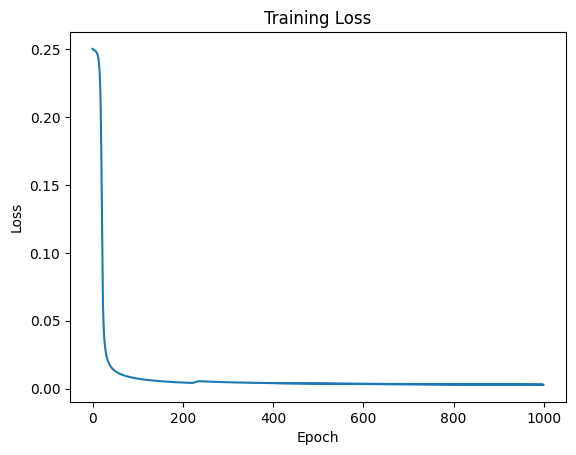

In [6]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

Accuracy

In [7]:
predictions = (output > 0.5).astype(int)

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy*100,"%")

Accuracy: 99.6 %
